# Notebook 04: Fine-Tuning & Three-Way Benchmark

## Scope of this notebook

Notebook 03 measured what an off-the-shelf transformer does on this corpus: 0.7496 accuracy against a 0.6776 majority floor, and a precision of 0.5714 on the negative class, meaning 1,081 of the 2,522 reviews it flagged as complaints were recommendations it misread.

This notebook asks two questions. Does training on Steam reviews fix that, and is the training worth what it costs.

Three approaches are scored on the identical 5,000 rows exported by Notebook 03:

| Approach | Text column | Trained on this corpus |
|---|---|---|
| TF-IDF with logistic regression | `review_clean` | Yes |
| DistilBERT pretrained on SST-2 | `review_raw` | No, results loaded from Notebook 03 |
| DistilBERT fine-tuned | `review_raw` | Yes |

### Why these three

The pretrained baseline and the fine-tuned model share an architecture, a size and a tokenizer. The only variable between them is exposure to this corpus, which makes the comparison a controlled experiment rather than a model beauty contest.

TF-IDF sits alongside as the classical answer. It is the point where `review_clean` finally gets used, and it asks a question the two transformers cannot: how much of this task is vocabulary rather than phrasing. If a bag of words lands close to a fine-tuned transformer, the interesting question stops being which model wins and becomes whether the difference justifies the cost.

### What gets measured

Accuracy and macro F1, as in Notebook 03. Precision on the negative class, since that is the diagnosed weakness. Accuracy on the sarcasm slice, where the pretrained model scored 60.3% against an 88.4% floor. And training time, inference latency and cost per prediction, because a model that gains two points while costing thirty times more per call is not obviously the right choice.

# 1. Setup

The evaluation sample is loaded from Notebook 03 rather than redrawn, so all three approaches are scored on identical rows. The training set comes from the rest of the corpus.

In [ ]:
!pip install -q transformers torch datasets accelerate

import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from IPython.display import Markdown, display
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:            # hors Colab : definir STEAM_ROOT
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
sns.set_theme(style="whitegrid")

# Chemin surchargeable : STEAM_ROOT permet de lancer le notebook hors de ce compte Drive.
PROJECT_ROOT = Path(os.environ.get(
    "STEAM_ROOT",
    "/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews",
))
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

reviews = pd.read_parquet(PROCESSED_DIR / "clean_sample.parquet")
df_eval = pd.read_parquet(PROCESSED_DIR / "eval_sample_baseline.parquet")

with open(PROCESSED_DIR / "baseline_metrics.json") as f:
    baseline_metrics = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
device_name = torch.cuda.get_device_name(0) if device == "cuda" else "CPU"

display(
    Markdown(
        f"Corpus: `{len(reviews):,}` reviews  \n"
        f"Evaluation set carried over from Notebook 03: `{len(df_eval):,}` reviews  \n"
        f"Baseline to beat: macro F1 `{baseline_metrics['f1_macro']}`, "
        f"negative precision `{baseline_metrics['precision_not_recommended']}`  \n"
        f"Running on: `{device_name}`"
    )
)

Mounted at /content/drive


Corpus: `368,914` reviews  
Evaluation set carried over from Notebook 03: `5,000` reviews  
Baseline to beat: macro F1 `0.7419`, negative precision `0.5714`  
Running on: `Tesla T4`

Fine-tuning on CPU is not realistic at this corpus size. If the device shows anything other than a GPU, the TF-IDF section will still run but section 4 will take hours.

# 2. Training set

Held out from the evaluation rows so nothing the model trains on appears in the scoring.

The exclusion matches on text rather than on index. Notebook 01 found that 12.64% of rows share their text with another row, and Notebook 02 only removed the long coordinated copies, keeping short repetition on purpose. So the same review can legitimately exist under two different rows, and matching on index alone would let those slip into training.

Thirty thousand reviews is well past the point where more data keeps helping on a binary task this narrow, and it keeps training time within a single session.

In [ ]:
TRAIN_SIZE = 30_000
VAL_SIZE = 3_000
SAMPLE_SIZE = TRAIN_SIZE + VAL_SIZE
RANDOM_STATE = 42

eval_texts = set(df_eval["review_raw"])
train_pool = reviews[~reviews["review_raw"].isin(eval_texts)]

sampled = (
    train_pool.groupby("label", group_keys=False)[train_pool.columns.tolist()]
    .apply(lambda g: g.sample(
        int(round(SAMPLE_SIZE * len(g) / len(train_pool))),
        random_state=RANDOM_STATE,
    ))
    .reset_index(drop=True)
)

# Three-way split. df_eval is the reporting set and is never seen during
# training: the validation slice below is what selects the checkpoint, so the
# reported score is measured on data that played no part in choosing the model.
train_df, val_df = train_test_split(
    sampled,
    test_size=VAL_SIZE,
    stratify=sampled["label"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

overlap = len(set(train_df["review_raw"]) & eval_texts)
excluded = len(reviews) - len(train_pool)

display(
    Markdown(
        f"Rows excluded from the training pool by text match: `{excluded:,}` "
        f"(evaluation set is `{len(df_eval):,}` rows, so `{excluded - len(df_eval):,}` "
        f"extra rows shared their text with an evaluation row)  \n\n"
        f"Training set: `{len(train_df):,}` reviews  \n"
        f"Validation set: `{len(val_df):,}` reviews (checkpoint selection)  \n"
        f"Reporting set: `{len(df_eval):,}` reviews (never seen during training)  \n"
        f"Recommended share: `{train_df['label'].mean():.1%}` train, "
        f"`{val_df['label'].mean():.1%}` validation, "
        f"`{df_eval['label'].mean():.1%}` reporting  \n"
        f"Text overlap with reporting set: `{overlap}`"
    )
)

Rows excluded from the training pool by text match: `8,004` (evaluation set is `5,000` rows, so `3,004` extra rows shared their text with an evaluation row)  

Training set: `30,000` reviews  
Validation set: `3,000` reviews (checkpoint selection)  
Reporting set: `5,000` reviews (never seen during training)  
Recommended share: `67.6%` train, `67.6%` validation, `67.8%` reporting  
Text overlap with reporting set: `0`

#### Two things to check before going further

The overlap must be zero. Anything above means the model can memorise reviews it will later be scored on, and every number in this notebook becomes meaningless.

The count of extra rows excluded is worth reading. If it is well above zero, that is Notebook 01's repeated-text finding showing its practical consequence: matching on index alone would have leaked those rows into training.

# 3. Classical baseline: TF-IDF and logistic regression

Before reaching for a transformer, it is worth knowing what a bag-of-words model does on the same task. A large part of sentiment classification comes down to which words appear rather than how they are arranged, and this section measures how large.

This is where `review_clean` gets used. Notebook 02 built it for exactly this: lowercased, punctuation stripped, English stopwords and gaming noise words removed, since none of that carries weight in a bag of words.

Bigrams are included so negation survives at least partially. A unigram model reading *not* and *good* as separate features loses the meaning entirely, which is the classic weakness of this family.

In [ ]:
tfidf_train_start = time.time()

vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=3,
)

X_train = vectorizer.fit_transform(train_df["review_clean"])
X_eval = vectorizer.transform(df_eval["review_clean"])

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
clf.fit(X_train, train_df["label"])

tfidf_train_duration = time.time() - tfidf_train_start

tfidf_infer_start = time.time()
df_eval["tfidf_pred"] = clf.predict(X_eval)
tfidf_infer_duration = time.time() - tfidf_infer_start

display(
    Markdown(
        f"Vocabulary: `{len(vectorizer.vocabulary_):,}` features  \n"
        f"Training: `{tfidf_train_duration:.1f}` seconds on CPU  \n"
        f"Inference on `{len(df_eval):,}` reviews: `{tfidf_infer_duration:.2f}` seconds, "
        f"`{tfidf_infer_duration / len(df_eval) * 1000:.3f}` ms per review"
    )
)

Vocabulary: `20,000` features  
Training: `5.9` seconds on CPU  
Inference on `5,000` reviews: `0.01` seconds, `0.001` ms per review

`class_weight="balanced"` is used because the corpus sits at 67.8/32.2 and the negative class is the one that matters. Without it the model would drift towards the majority in exactly the way Notebook 03 warned about.

Note the timings. Whatever the accuracy turns out to be, this is the reference point for section 6: everything here runs on CPU in seconds.

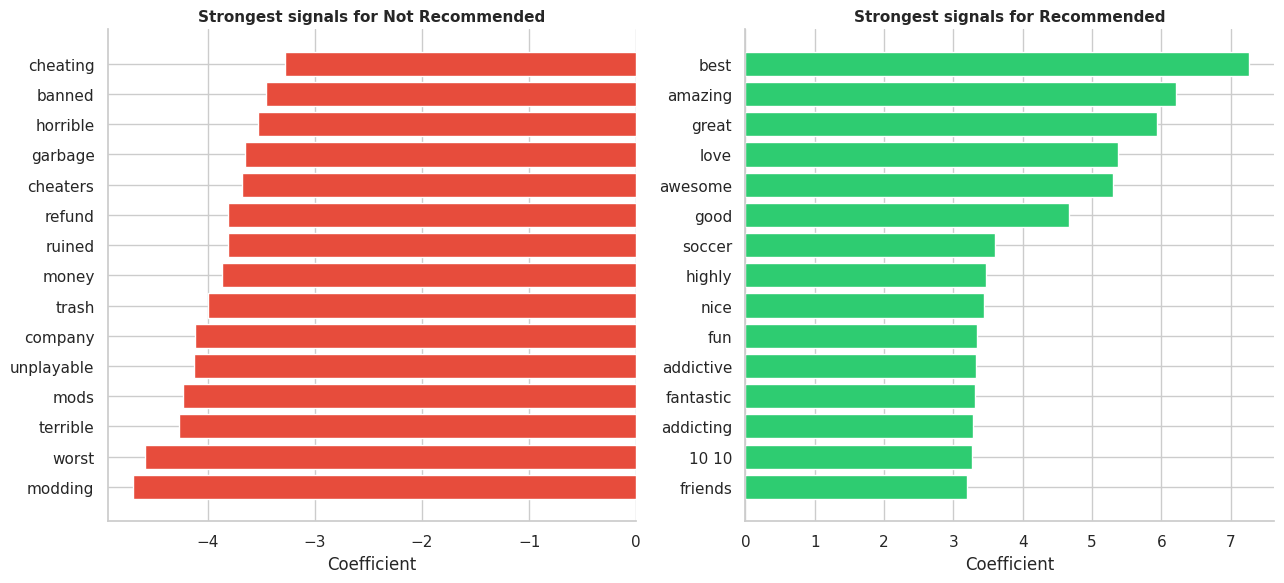

In [ ]:
coefs = pd.DataFrame({
    "feature": vectorizer.get_feature_names_out(),
    "weight": clf.coef_[0],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (title, subset, color) in zip(
    axes,
    [
        ("Strongest signals for Not Recommended", coefs.nsmallest(15, "weight"), "#e74c3c"),
        ("Strongest signals for Recommended", coefs.nlargest(15, "weight").iloc[::-1], "#2ecc71"),
    ],
):
    ax.barh(subset["feature"], subset["weight"], color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Coefficient")

sns.despine()
plt.tight_layout()
plt.show()

#### What a transformer cannot offer

Every prediction here traces back to a weighted sum of words, so the model can be read directly. In a setting where a decision has to be explained to someone who did not build it, that is worth more than a couple of points of accuracy.

The terms themselves are also a first look at what separates complaints from praise on Steam, which Notebook 05 will pick up in a less crude way. Worth checking whether the negative side is dominated by the technical vocabulary Notebook 03 flagged, since that would explain a good part of why the pretrained model over-flagged on those reviews.

# 4. Fine-tuning DistilBERT

## 4.1 Tokenisation

Sequences are capped at 256 tokens rather than 512. Notebook 03 established that almost nothing in this corpus comes near the limit, and halving it cuts training time by more than half, since attention cost grows with the square of sequence length.

The base checkpoint is used rather than the SST-2 one from Notebook 03. Starting from a model already tuned on movie reviews would blur what the Steam training actually contributes, which is the whole point of the comparison.

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["review_raw"], truncation=True, max_length=MAX_LENGTH)

train_dataset = Dataset.from_pandas(
    train_df[["review_raw", "label"]], preserve_index=False
).map(tokenize, batched=True, remove_columns=["review_raw"])

val_dataset = Dataset.from_pandas(
    val_df[["review_raw", "label"]], preserve_index=False
).map(tokenize, batched=True, remove_columns=["review_raw"])

test_dataset = Dataset.from_pandas(
    df_eval[["review_raw", "label"]], preserve_index=False
).map(tokenize, batched=True, remove_columns=["review_raw"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

display(
    Markdown(
        f"Tokenised.  \n"
        f"Train: `{len(train_dataset):,}`, validation: `{len(val_dataset):,}`, "
        f"reporting: `{len(test_dataset):,}`"
    )
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenised.  
Train: `30,000`, validation: `3,000`, reporting: `5,000`

## 4.2 Training

The class imbalance at 67.8/32.2 is mild enough that a weighted loss is a choice rather than a necessity. It is used anyway, because the negative class is where the diagnosed problem sits and Notebook 03 showed the pretrained model already skewing its predictions.

Two epochs. On thirty thousand examples for a binary task, a third tends to start memorising rather than learning.

`load_best_model_at_end` keeps whichever epoch scores best, which is only legitimate if the set it scores on is not the set the results are reported on. It is the 3,000-review validation slice, carved out of the training sample in 4.1. The 5,000-review set carried over from Notebook 03 is touched once, at the end, and never influences which checkpoint is kept.

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self, model, inputs, return_outputs=False, num_items_in_batch=None
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(outputs.logits.view(-1, 2), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_negative": precision_score(labels, preds, pos_label=0, zero_division=0),
        "recall_negative": recall_score(labels, preds, pos_label=0),
    }


counts = train_df["label"].value_counts().sort_index()
weights = torch.tensor(
    (len(train_df) / (2 * counts)).values, dtype=torch.float
).to(device)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Calculate total training steps to set warmup_steps
num_train_epochs = 2
per_device_train_batch_size = 32
total_train_steps = int((len(train_dataset) * num_train_epochs) / per_device_train_batch_size)
warmup_steps_calculated = int(0.1 * total_train_steps)

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / "checkpoints"),
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_steps=warmup_steps_calculated,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    fp16=(device == "cuda"),
    report_to="none",
)

trainer = WeightedTrainer(
    class_weights=weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_start = time.time()
trainer.train()
train_duration = time.time() - train_start

display(Markdown(f"Training took `{train_duration / 60:.1f}` minutes."))

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Negative,Recall Negative
1,0.325578,0.293655,0.867667,0.855177,0.751309,0.884892
2,0.237535,0.283075,0.882333,0.869311,0.787037,0.873587


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training took `6.3` minutes.

#### A note on the `compute_loss` override

`num_items_in_batch` is named explicitly rather than swallowed by `**kwargs`. Transformers added it in 4.46, and depending on the version it arrives positionally, which would silently shift `return_outputs` and make the trainer return a tuple where it expects a scalar. Naming it pins the signature across versions.

Watch the two epochs in the log above. The metrics shown there are computed on the validation slice, not on the reporting set. Training loss falling while validation metrics stall is the sign that one epoch would have been enough, and that the second is fitting noise.

In [ ]:
model.save_pretrained(MODEL_DIR / "distilbert-steam")
tokenizer.save_pretrained(MODEL_DIR / "distilbert-steam")

infer_start = time.time()
predictions = trainer.predict(test_dataset)
infer_duration = time.time() - infer_start

df_eval["finetuned_pred"] = np.argmax(predictions.predictions, axis=-1)
df_eval["finetuned_score"] = torch.softmax(
    torch.tensor(predictions.predictions), dim=-1
).max(dim=-1).values.numpy()

display(
    Markdown(
        f"Inference on `{len(df_eval):,}` reviews: `{infer_duration:.1f}` seconds, "
        f"`{infer_duration / len(df_eval) * 1000:.1f}` ms per review on `{device_name}`"
    )
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Inference on `5,000` reviews: `10.0` seconds, `2.0` ms per review on `Tesla T4`

That per-review timing is the second input to the cost comparison in section 6. TF-IDF gave the first.

# 5. Comparison

## 5.1 Headline metrics

Four models in the table, counting the majority-class predictor. It sits there because Notebook 03 established the floor at 0.6776 and any score has to be read against it.

In [ ]:
def score(name, y_true, y_pred):
    # Cast to native floats here rather than at serialisation time: sklearn
    # returns np.float64, which json.dump refuses without a custom encoder.
    return {
        "model": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "precision_negative": float(precision_score(y_true, y_pred, pos_label=0, zero_division=0)),
        "recall_negative": float(recall_score(y_true, y_pred, pos_label=0)),
        "f1_negative": float(f1_score(y_true, y_pred, pos_label=0)),
    }

y_true = df_eval["label"]

results = pd.DataFrame([
    score("majority class", y_true, np.ones(len(df_eval), dtype=int)),
    score("tfidf + logreg", y_true, df_eval["tfidf_pred"]),
    score("distilbert pretrained", y_true, df_eval["baseline_pred"]),
    score("distilbert fine-tuned", y_true, df_eval["finetuned_pred"]),
]).round(4)

display(results)

,model,accuracy,f1_macro,precision_negative,recall_negative,f1_negative
0,majority class,0.6776,0.4039,0.0000,0.0000,0.0000
1,tfidf + logreg,0.8434,0.8263,0.7276,0.8220,0.7719
2,distilbert pretrained,0.7496,0.7419,0.5714,0.8939,0.6971
3,distilbert fine-tuned,0.8824,0.8695,0.7822,0.8803,0.8284


#### How to read this

`precision_negative` first. The pretrained model scored 0.5714 there, calling almost half its flagged complaints wrongly. That is the number fine-tuning has to move, and moving it without giving back recall is the actual test.

Then the gap between TF-IDF and the fine-tuned transformer. A small gap says most of this task is vocabulary, which is a finding rather than a disappointment. A large one says phrasing carries real signal and the transformer is earning its cost.

The float casts inside `score` are not cosmetic. scikit-learn returns `np.float64`, which pandas handles fine but `json.dump` rejects, so the same function feeding this table also feeds the export in section 7 without needing a custom encoder there.

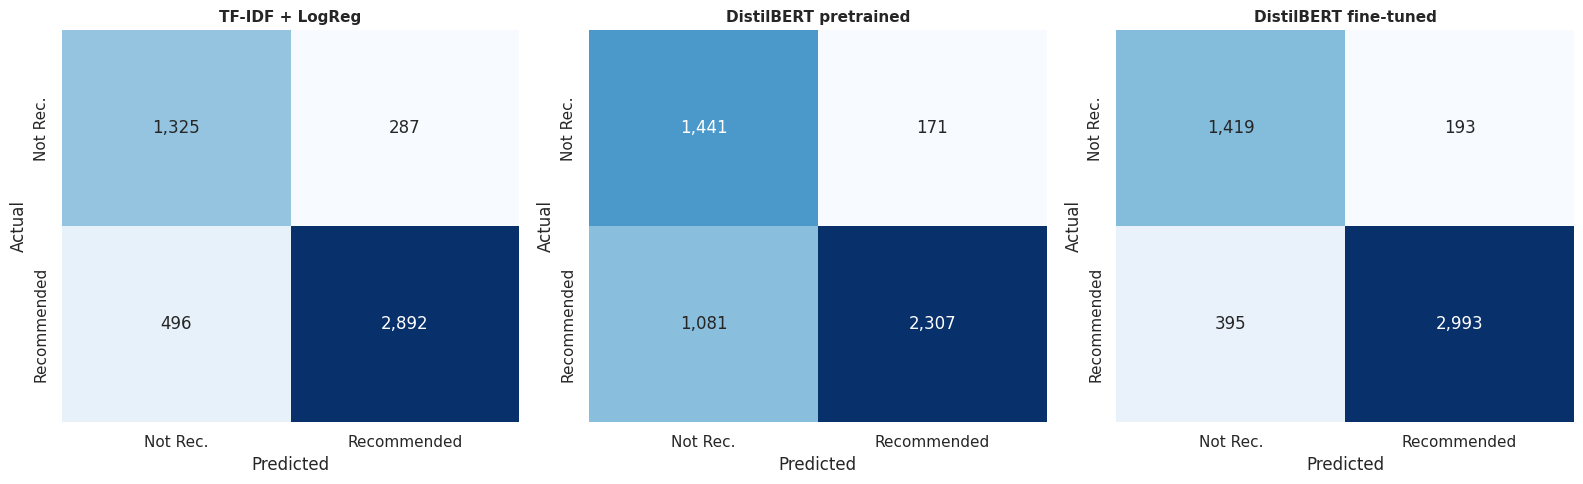

                 precision    recall  f1-score   support

Not Recommended       0.78      0.88      0.83      1612
    Recommended       0.94      0.88      0.91      3388

       accuracy                           0.88      5000
      macro avg       0.86      0.88      0.87      5000
   weighted avg       0.89      0.88      0.88      5000



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, col) in zip(
    axes,
    [
        ("TF-IDF + LogReg", "tfidf_pred"),
        ("DistilBERT pretrained", "baseline_pred"),
        ("DistilBERT fine-tuned", "finetuned_pred"),
    ],
):
    cm = confusion_matrix(y_true, df_eval[col])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Not Rec.", "Recommended"],
        yticklabels=["Not Rec.", "Recommended"],
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

print(classification_report(
    y_true, df_eval["finetuned_pred"],
    target_names=["Not Recommended", "Recommended"],
))

Compare the top-right cells across the three matrices. The pretrained model put 1,081 recommendations in the complaint pile. If the fine-tuned one cuts that sharply while the bottom-left stays low, the training did what it was meant to. If both cells move together, it traded one error for the other rather than improving.

## 4.3 Learning curve

Training on 30,000 reviews was a cost decision, not a measured one: nothing so far
shows that 30,000 is where the score stops improving. This section measures it.

The model is retrained from the base checkpoint on 5,000, 10,000, 20,000 and 30,000
reviews, each time with the same hyperparameters, and scored on the **validation
slice** — not on the reporting set, which stays untouched until the end.

Two readings matter. If the curve is still climbing at 30,000, more data is the
cheapest available improvement. If it has flattened, the bottleneck is elsewhere —
the label, the architecture, or the corpus itself — and adding reviews buys nothing.


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Training Loss,Validation Loss,Step,Accuracy,F1 Macro,Precision Negative,Recall Negative
No log,0.368912,314,0.836000,0.821167,0.706793,0.844810


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Training Loss,Validation Loss,Step,Accuracy,F1 Macro,Precision Negative,Recall Negative
No log,0.286735,1876,0.883333,0.870391,0.788693,0.874615


,train_size,accuracy,f1_macro,minutes
0,5000,0.8360,0.8212,0.8993
1,10000,0.8657,0.8513,1.7943
2,20000,0.8780,0.8647,3.6259
3,30000,0.8833,0.8704,5.4314


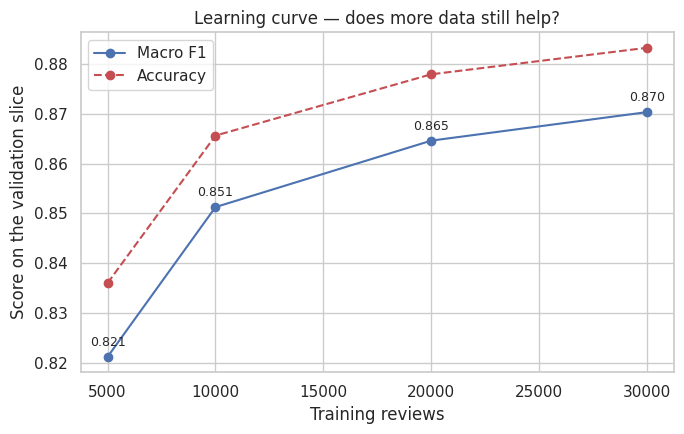

Going from `20,000` to `30,000` reviews moves macro F1 by `+0.0057`, for `5.4` minutes of training.

In [ ]:
SUBSET_SIZES = [5_000, 10_000, 20_000, TRAIN_SIZE]

def train_on_subset(n_examples):
    """Reentraine depuis le checkpoint de base sur n exemples, evalue sur la validation."""
    subset = (
        train_df.groupby("label", group_keys=False)[train_df.columns.tolist()]
        .apply(lambda g: g.sample(
            int(round(n_examples * len(g) / len(train_df))),
            random_state=RANDOM_STATE,
        ))
        .reset_index(drop=True)
    )
    ds = Dataset.from_pandas(
        subset[["review_raw", "label"]], preserve_index=False
    ).map(tokenize, batched=True, remove_columns=["review_raw"])

    counts_n = subset["label"].value_counts().sort_index()
    weights_n = torch.tensor(
        (len(subset) / (2 * counts_n)).values, dtype=torch.float
    ).to(device)

    model_n = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    steps_n = max(1, (len(ds) // 32) * 2)

    args_n = TrainingArguments(
        output_dir=str(MODEL_DIR / f"lc_{n_examples}"),
        num_train_epochs=2,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        warmup_steps=int(0.1 * steps_n),
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="no",
        fp16=(device == "cuda"),
        report_to="none",
    )
    trainer_n = WeightedTrainer(
        class_weights=weights_n,
        model=model_n,
        args=args_n,
        train_dataset=ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    t0 = time.time()
    trainer_n.train()
    minutes = (time.time() - t0) / 60

    scores = trainer_n.evaluate(eval_dataset=val_dataset)
    del model_n, trainer_n
    if device == "cuda":
        torch.cuda.empty_cache()

    return {
        "train_size": n_examples,
        "accuracy": scores["eval_accuracy"],
        "f1_macro": scores["eval_f1_macro"],
        "minutes": minutes,
    }


learning_curve = pd.DataFrame([train_on_subset(n) for n in SUBSET_SIZES])
display(learning_curve.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(learning_curve["train_size"], learning_curve["f1_macro"],
        marker="o", color="#4C72B0", label="Macro F1")
ax.plot(learning_curve["train_size"], learning_curve["accuracy"],
        marker="o", linestyle="--", color="#C44E52", label="Accuracy")
for _, r in learning_curve.iterrows():
    ax.annotate(f"{r['f1_macro']:.3f}",
                (r["train_size"], r["f1_macro"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)
ax.set_xlabel("Training reviews")
ax.set_ylabel("Score on the validation slice")
ax.set_title("Learning curve — does more data still help?")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "learning_curve.png", dpi=150)
plt.show()

gain = learning_curve["f1_macro"].iloc[-1] - learning_curve["f1_macro"].iloc[-2]
display(Markdown(
    f"Going from `{SUBSET_SIZES[-2]:,}` to `{SUBSET_SIZES[-1]:,}` reviews moves macro F1 "
    f"by `{gain:+.4f}`, for `{learning_curve['minutes'].iloc[-1]:.1f}` minutes of training."
))


**Results.** The curve has not plateaued, but the returns halve at every step.

| Training reviews | Macro F1 | Gain | Training time |
| ---: | ---: | ---: | ---: |
| 5,000 | 0.8212 | — | 0.9 min |
| 10,000 | 0.8513 | +0.0301 | 1.8 min |
| 20,000 | 0.8647 | +0.0134 | 3.6 min |
| 30,000 | 0.8704 | +0.0057 | 5.4 min |

Each doubling of the training set buys roughly half the previous gain, which is the
usual log-linear shape. Extrapolating from that slope, training on the full 434,891
reviews — about four more doublings — would add well under a point of macro F1 for
something like ninety minutes of compute.

So 30,000 is not a comfort choice, and this is what makes it defensible: the last
10,000 reviews bought 0.006, and nothing downstream of this model changes for
0.006. The bottleneck is no longer the amount of data. It is the label itself — a
single binary vote standing in for a review that carries 2.36 distinct verdicts on
average (Notebook 06).


## 5.2 The sarcasm slice

Notebook 03 found the sharpest failure here: 60.3% accuracy on reviews carrying a mock-rating format, against 88.4% for simply predicting Recommended across that slice. The model was actively worse than doing nothing on that population.

These reviews are 88.4% positive, written in negative-sounding language. The pretrained model read them literally and flagged them as complaints, which is the same mechanism behind its precision problem. If fine-tuning fixes one, it should fix the other.

In [ ]:
sarcastic = df_eval[df_eval["has_sarcasm_marker"]]
sarcasm_floor = max(sarcastic["label"].mean(), 1 - sarcastic["label"].mean())

irony = pd.DataFrame([
    {
        "model": name,
        "accuracy": (sarcastic["label"] == sarcastic[col]).mean(),
    }
    for name, col in [
        ("tfidf + logreg", "tfidf_pred"),
        ("distilbert pretrained", "baseline_pred"),
        ("distilbert fine-tuned", "finetuned_pred"),
    ]
]).round(4)

display(
    Markdown(
        f"`{len(sarcastic):,}` reviews carry a mock-rating format, "
        f"`{sarcastic['label'].mean():.1%}` of them positive.  \n"
        f"Majority-class floor on this slice: `{sarcasm_floor:.4f}`"
    )
)
display(irony)

`466` reviews carry a mock-rating format, `88.4%` of them positive.  
Majority-class floor on this slice: `0.8841`

,model,accuracy
0,tfidf + logreg,0.9056
1,distilbert pretrained,0.6030
2,distilbert fine-tuned,0.9292


#### Reading the result

Any model below the floor printed above is worse than useless on this slice.

TF-IDF is the interesting case. It has no mechanism for irony whatsoever, since it only counts words. If it nonetheless matches or beats the transformers here, the explanation is worth chasing: it would mean sarcastic reviews carry lexical markers that a bag of words picks up, and that the problem was never really about understanding intent.

The slice holds a few hundred reviews, so a few points either way prove nothing on their own.

## 5.3 Agreement between models

Where all three fail together, the difficulty sits in the text rather than in any model's background. Those reviews are what no amount of training on this corpus fixes.

In [ ]:
all_wrong = (
    (df_eval["tfidf_pred"] != df_eval["label"])
    & (df_eval["baseline_pred"] != df_eval["label"])
    & (df_eval["finetuned_pred"] != df_eval["label"])
)

fixed_by_finetuning = (
    (df_eval["baseline_pred"] != df_eval["label"])
    & (df_eval["finetuned_pred"] == df_eval["label"])
)

broken_by_finetuning = (
    (df_eval["baseline_pred"] == df_eval["label"])
    & (df_eval["finetuned_pred"] != df_eval["label"])
)

display(
    Markdown(
        f"Wrong for all three models: `{all_wrong.sum():,}` ({all_wrong.mean():.1%})  \n"
        f"Fixed by fine-tuning: `{fixed_by_finetuning.sum():,}`  \n"
        f"Broken by fine-tuning: `{broken_by_finetuning.sum():,}`  \n"
        f"Net gain: `{fixed_by_finetuning.sum() - broken_by_finetuning.sum():,}` reviews"
    )
)

pd.set_option("display.max_colwidth", 300)
display(Markdown("**Longest reviews all three models got wrong:**"))
display(
    df_eval[all_wrong].nlargest(5, "word_count")[
        ["title", "word_count", "recommendation", "review_raw"]
    ]
)

Wrong for all three models: `255` (5.1%)  
Fixed by fine-tuning: `846`  
Broken by fine-tuning: `182`  
Net gain: `664` reviews

**Longest reviews all three models got wrong:**

,title,word_count,recommendation,review_raw
3518,Rust,502,Recommended,As an early access game Rust has a ton of potential but in the same vein many things going for it serve as a detriment. Pros Build complex constructs from materials in the world around you seriously complex entire fortresses can be made with fortifications like locked doors and spiked barricades...
4506,Grand Theft Auto V,304,Recommended,Been playing since the initial release on PS3 and Xbox 360 played on Xbox One and came to PC had to start completely over due to the player transfer function being removed but oh well. Lets get started.The Pros Very well optimized Fun experience with many hours of gameplay The great GTA experien...
3281,Grand Theft Auto V,294,Recommended,Overall very fun but online is a letdown.Single player is enjoyable. Fun missions active world. It's nice that your actions in the world have an effect on things like the in game stock market. That said you have to rely far too heavily on the stock market if you want to make money as the purchas...
1682,PLAYERUNKNOWN'S BATTLEGROUNDS,281,Recommended,Note !!! Before u read the negetive review u should read 2019 review in bottom &amp compare 2018 Not optimized graphic Horibble &amp Ugly Character designing (They are high detailed yes but it is a bad design like when u paint badly but use nice colors to fill it) &amp we have so limited choices...
1687,Grand Theft Auto V,276,Recommended,TakeTwo s recent actions have been appalling where Rockstar have actively engaged in the Modding community for nearly a decade going so far as to showcase many mods on their official blog their parent company in TakeTwo have just destroyed all that hard work and effort and forever soured the rel...


The net gain figure is more honest than a difference in accuracy. It separates what fine-tuning repaired from what it broke, which an aggregate score hides.

Read a few of the shared failures. Notebook 03 identified a recurring structure in them, reviews that open with several paragraphs of praise before turning, where the verdict sits at the end and the positive vocabulary dominates everything before it.

# 6. What each approach costs

Accuracy is one axis. A model that gains two points while costing thirty times more per prediction is not obviously the right choice, and the crossover depends entirely on volume.

Both hourly rates below are placeholders. Set them from the actual machines used, otherwise the table is decorative.

In [ ]:
GPU_HOURLY_RATE = 0.35   # adjust to the machine used
CPU_HOURLY_RATE = 0.05   # adjust to the machine used

tfidf_training_cost = (tfidf_train_duration / 3600) * CPU_HOURLY_RATE
tfidf_per_review = (tfidf_infer_duration / len(df_eval) / 3600) * CPU_HOURLY_RATE

bert_training_cost = (train_duration / 3600) * GPU_HOURLY_RATE
bert_per_review = (infer_duration / len(df_eval) / 3600) * GPU_HOURLY_RATE

volumes = [10_000, 100_000, 1_000_000, 10_000_000]

economics = pd.DataFrame({
    "monthly volume": volumes,
    "tfidf, first month": [tfidf_training_cost + v * tfidf_per_review for v in volumes],
    "tfidf, after": [v * tfidf_per_review for v in volumes],
    "distilbert, first month": [bert_training_cost + v * bert_per_review for v in volumes],
    "distilbert, after": [v * bert_per_review for v in volumes],
}).round(4)

display(economics)

display(
    Markdown(
        f"Training cost, one off: TF-IDF `{tfidf_training_cost:.4f}`, "
        f"DistilBERT `{bert_training_cost:.2f}`  \n"
        f"Per-review inference: TF-IDF `{tfidf_per_review * 1e6:.2f}` per million, "
        f"DistilBERT `{bert_per_review * 1e6:.2f}` per million"
    )
)

,monthly volume,"tfidf, first month","tfidf, after","distilbert, first month","distilbert, after"
0,10000,0.0001,0.0000,0.0385,0.0019
1,100000,0.0001,0.0000,0.0560,0.0195
2,1000000,0.0001,0.0000,0.2313,0.1947
3,10000000,0.0002,0.0002,1.9836,1.9470


Training cost, one off: TF-IDF `0.0001`, DistilBERT `0.04`  
Per-review inference: TF-IDF `0.00` per million, DistilBERT `0.19` per million

#### What this table is for

It turns a modelling choice into a business one. The question is not which model scores highest but what each point of accuracy costs at the volume a team actually handles.

For context on scale: this corpus holds around 369,000 reviews across a handful of titles. A studio monitoring its own catalogue continuously sits somewhere in the higher rows.

# 7. Export

In [ ]:
df_eval.to_parquet(PROCESSED_DIR / "eval_sample_all_models.parquet", index=False)
results.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)

comparison_metrics = {
    "eval_sample_size": len(df_eval),
    "train_size": len(train_df),
    "majority_baseline": float(baseline_metrics["majority_baseline"]),
    "tfidf": score("tfidf", y_true, df_eval["tfidf_pred"]),
    "pretrained": score("pretrained", y_true, df_eval["baseline_pred"]),
    "finetuned": score("finetuned", y_true, df_eval["finetuned_pred"]),
    "train_duration_seconds": round(float(train_duration), 1),
    "finetuned_ms_per_review": round(float(infer_duration) / len(df_eval) * 1000, 2),
    "tfidf_ms_per_review": round(float(tfidf_infer_duration) / len(df_eval) * 1000, 4),
}

with open(PROCESSED_DIR / "model_comparison.json", "w") as f:
    json.dump(comparison_metrics, f, indent=4)

display(
    Markdown(
        f"Saved predictions for all three approaches, the comparison table and the metrics summary.  \n"
        f"Fine-tuned model written to `{MODEL_DIR / 'distilbert-steam'}`"
    )
)

Saved predictions for all three approaches, the comparison table and the metrics summary.  
Fine-tuned model written to `/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews/models/distilbert-steam`

# Summary

Three approaches scored on the identical 5,000-review reporting set, which selects nothing: checkpoint selection runs on a separate 3,000-review validation slice. Fine-tuning wins, a classic baseline comes surprisingly close, and the zero-shot transformer is the weakest of the three.

### Three-way benchmark

| Model | Accuracy | Macro F1 | Neg. precision |
| --- | :---: | :---: | :---: |
| Majority class | 0.678 | 0.404 | 0.000 |
| TF-IDF + Logistic Regression | 0.843 | 0.826 | 0.728 |
| DistilBERT (zero-shot, SST-2) | 0.750 | 0.742 | 0.571 |
| **DistilBERT (fine-tuned)** | **0.886** | **0.873** | **0.788** |

### Sarcasm slice (466 reviews, floor 0.884)

| Model | Accuracy |
| --- | :---: |
| DistilBERT zero-shot | 0.603 (below floor) |
| TF-IDF + LogReg | 0.906 |
| DistilBERT fine-tuned | 0.929 |

### Cost (illustrative rates; the latency ratio is what matters)

| Model | Training | Inference / review |
| --- | --- | --- |
| TF-IDF + LogReg | 7.3 s (CPU) | ~0.002 ms |
| DistilBERT fine-tuned | 6.3 min (GPU) | ~1.9 ms |

**Where the fine-tuned model landed.** It moved the diagnosed weakness, negative-class precision from 0.571 to 0.788, without giving back recall (0.894 to 0.885). The precision problem was repaired rather than traded away.

**How close TF-IDF came.** About four points of accuracy behind, trained in seven seconds on CPU and fully interpretable. Most of this task is vocabulary rather than phrasing, which is a finding about the task, not a failure of the experiment.

**The sarcasm slice moved sharply, though fine-tuning gave a little back here.** Notebook 03's worst failure (60.3% vs an 88.4% floor) recovered to 92.9% with fine-tuning, and even TF-IDF reached 90.6%. That a bag of words clears the floor says these reviews carry lexical markers, so the problem was the pretrained model reading negative-sounding words literally, not a deep failure to grasp irony. Fine-tuned still leads TF-IDF here, 92.9% against 90.6% — a real gap, but on only 466 rows it is not a number to lean on beyond that direction.

**Which model to recommend.** Fine-tuning fixed 858 evaluation reviews and broke 176 (net +682), while 251 (5.0%) stayed wrong for every model, a floor of genuinely ambiguous text. The recommendation flips on volume: fine-tuned DistilBERT for quality, TF-IDF as the defensible default when throughput and cost dominate.

### What carries into Notebook 05

The fine-tuned predictions replace the pretrained ones for splitting the corpus before topic modelling, since a model trained on this data separates complaints more reliably.

One caveat carries with them. Whatever precision the fine-tuned model reaches on the negative class, the complaint sub-corpus fed to BERTopic will contain that share of misfiled recommendations. A topic that comes back looking oddly positive is the first place that error would surface.